In [34]:
# Install uv for fast package management
!pip install uv

# Install required libraries
!uv pip install seaborn torch torchvision wandb fiftyone huggingface_hub scikit-learn matplotlib tqdm --system

Using Python 3.11.11 environment at: C:\Users\Philipp\miniconda3
Audited 9 packages in 4.14s


In [35]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import Adam
import torch.nn.functional as F
import torchvision.transforms as transforms

from torch.utils.data import Dataset, DataLoader
import fiftyone as fo
import fiftyone.utils.huggingface as fouh
import wandb
from tqdm import tqdm
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns


# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [36]:
!hf auth login

User is already logged in.


In [37]:
!wandb login

wandb: Currently logged in as: hpi-philipp-kolbe (na_mst_2) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## 1. Load Dataset

In [38]:
# Configuration
HF_USERNAME = "philippkolbe" 
SUBSET_NAME = "cilp_assessment_subset"
HF_DATASET_REPO = f"{HF_USERNAME}/{SUBSET_NAME}"

# Load dataset from Hugging Face
print(f"Loading dataset from {HF_DATASET_REPO}...")
if fo.dataset_exists(SUBSET_NAME):
    print(f"Dataset '{SUBSET_NAME}' found locally. Loading...")
    dataset = fo.load_dataset(SUBSET_NAME)
else:
    print(f"Dataset '{SUBSET_NAME}' not found locally. Loading from Hugging Face ({HF_DATASET_REPO})...")
    try:
        dataset = fouh.load_from_hub(HF_DATASET_REPO, name=SUBSET_NAME)
        print("Dataset loaded successfully from Hub.")
    except Exception as e:
        print(f"Error loading dataset: {e}")

Loading dataset from philippkolbe/cilp_assessment_subset...
Dataset 'cilp_assessment_subset' found locally. Loading...


In [39]:
ground_truths = set(dataset.values("ground_truth.label"))
azimuths = {}
zeniths = {}

# Load Azimuth and Zenith data
for gt in ground_truths:
    try:
        azimuth = np.load(f"data/assessment/{gt}/azimuth.npy")
        azimuths[gt] = azimuth
        zenith = np.load(f"data/assessment/{gt}/zenith.npy")
        zeniths[gt] = zenith
    except FileNotFoundError:
        print(f"Warning: Metadata for {gt} not found locally. Ensure data/assessment is present.")

if azimuths:
    azimuth = next(iter(azimuths.values()))
    zenith = next(iter(zeniths.values()))
else:
    print("Error: No azimuth/zenith data found!")

## 2. Prepare Data Loaders

In [40]:
def get_torch_xyza(lidar_depth, azimuth, zenith):
    x = lidar_depth * torch.sin(-azimuth[:, None]) * torch.cos(-zenith[None, :])
    y = lidar_depth * torch.cos(-azimuth[:, None]) * torch.cos(-zenith[None, :])
    z = lidar_depth * torch.sin(-zenith[None, :])
    a = torch.where(lidar_depth < 50.0, torch.ones_like(lidar_depth), torch.zeros_like(lidar_depth))
    xyza = torch.stack((x, y, z, a))
    return xyza

IMG_SIZE = 64
BATCH_SIZE = 32

img_transforms = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
])

class MultimodalDataset(Dataset):
    def __init__(self, fiftyone_dataset, split, azimuth, zenith, transform):
        self.transform = transform
        self.samples = []
        
        view = fiftyone_dataset.match_tags(split)
        self.azimuth = torch.from_numpy(azimuth).to(device)
        self.zenith = torch.from_numpy(zenith).to(device)

        rgb_view = view.select_group_slices("rgb")
        lidar_view = view.select_group_slices("lidar")
        lidar_map = {s.group.id: s.filepath for s in lidar_view}
        
        for s in rgb_view:
            if s.group.id in lidar_map:
                rgb_filepath = s.filepath
                rgb_img = Image.open(rgb_filepath)
                rgb_img = self.transform(rgb_img).to(device)

                lidar_filepath = lidar_map[s.group.id]
                lidar_depth = np.load(lidar_filepath)
                lidar_depth = torch.from_numpy(lidar_depth).to(torch.float32).to(device)

                self.samples.append({
                    "rgb": rgb_img,
                    "lidar": lidar_depth,
                    "label": 0 if s.ground_truth.label == "cubes" else 1
                })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        item = self.samples[idx]
        rbg_img = item["rgb"]
        lidar_depth = item["lidar"]
        lidar_xyza = get_torch_xyza(lidar_depth, self.azimuth, self.zenith)
        label_tensor = torch.tensor(item["label"], dtype=torch.float32)
        return rbg_img, lidar_xyza, label_tensor

# Create Datasets & Loaders
train_dataset = MultimodalDataset(dataset, "train", azimuth, zenith, img_transforms)
val_dataset = MultimodalDataset(dataset, "val", azimuth, zenith, img_transforms)
test_dataset = MultimodalDataset(dataset, "test", azimuth, zenith, img_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Train: 505, Val: 123, Test: 122


## 3. Define Models

We use the **EmbedderMaxPool** architecture from Task 4 as the backbone, as it proved to be robust and effective.

**Note on Implementation Difference:**
You might see implementations that manually repeat tensors to calculate pairwise similarity (e.g., using `repeat_interleave` and `CosineSimilarity`). We use the standard **CLIP** approach: matrix multiplication of normalized embeddings (`rgb @ lidar.T`). 

*   **Efficiency**: Matrix multiplication is mathematically equivalent to calculating cosine similarity for all pairs but is significantly more memory and compute efficient ($O(N^2)$ vs $O(N^2 \cdot D)$ memory).
*   **Loss Formulation**: We use a learnable temperature parameter to scale logits before applying CrossEntropyLoss. This helps the Softmax produce sharper probability distributions compared to using raw cosine similarities (which are bounded in $[-1, 1]$) as logits.

In [41]:
class EmbedderMaxPool(nn.Module):
    def __init__(self, in_channels=4):
        super(EmbedderMaxPool, self).__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, 50, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2), # 64 -> 32
            nn.Conv2d(50, 100, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)  # 32 -> 16
        )
        
    def forward(self, x):
        return self.net(x)

class ContrastiveEncoder(nn.Module):
    def __init__(self, in_channels=4, embedding_dim=128):
        super(ContrastiveEncoder, self).__init__()
        self.backbone = EmbedderMaxPool(in_channels)
        self.flatten = nn.Flatten()
        # Output of backbone is 100 x 16 x 16 = 25600
        self.projection = nn.Sequential(
            nn.Linear(100 * 16 * 16, 512),
            nn.ReLU(),
            nn.Linear(512, embedding_dim)
        )
        
    def forward(self, x):
        features = self.backbone(x)
        flat = self.flatten(features)
        embedding = self.projection(flat)
        return embedding

class CILPModel(nn.Module):
    def __init__(self, embedding_dim=128, temperature=0.07):
        super(CILPModel, self).__init__()
        self.rgb_encoder = ContrastiveEncoder(in_channels=4, embedding_dim=embedding_dim)
        self.lidar_encoder = ContrastiveEncoder(in_channels=4, embedding_dim=embedding_dim)
        # Initialize temperature parameter (log scale for stability)
        self.temperature = nn.Parameter(torch.tensor(np.log(1/temperature)))
        
    def forward(self, rgb, lidar):
        rgb_emb = self.rgb_encoder(rgb)
        lidar_emb = self.lidar_encoder(lidar)
        
        # Normalize embeddings
        rgb_emb = F.normalize(rgb_emb, p=2, dim=1)
        lidar_emb = F.normalize(lidar_emb, p=2, dim=1)
        
        return rgb_emb, lidar_emb

## 4. Task 5.1: Contrastive Pretraining (CILP)

Train the RGB and LiDAR encoders to align their embeddings using Contrastive Loss (CLIP-style).

Starting CILP Pretraining...
Epoch 1/20 - Train Loss: 3.4521 - Val Loss: 3.3241
Epoch 2/20 - Train Loss: 2.6922 - Val Loss: 1.8294
Epoch 3/20 - Train Loss: 1.5467 - Val Loss: 1.0816
Epoch 4/20 - Train Loss: 0.9402 - Val Loss: 0.9752
Epoch 5/20 - Train Loss: 0.7383 - Val Loss: 0.7708
Epoch 6/20 - Train Loss: 0.6598 - Val Loss: 0.7182
Epoch 7/20 - Train Loss: 0.5540 - Val Loss: 0.6883
Epoch 8/20 - Train Loss: 0.4567 - Val Loss: 0.6885
Epoch 9/20 - Train Loss: 0.4421 - Val Loss: 0.6415
Epoch 10/20 - Train Loss: 0.3931 - Val Loss: 0.6531
Epoch 11/20 - Train Loss: 0.3315 - Val Loss: 0.6705
Epoch 12/20 - Train Loss: 0.3133 - Val Loss: 0.6255
Epoch 13/20 - Train Loss: 0.2823 - Val Loss: 0.6527
Epoch 14/20 - Train Loss: 0.2554 - Val Loss: 0.6030
Epoch 15/20 - Train Loss: 0.2173 - Val Loss: 0.6194
Epoch 16/20 - Train Loss: 0.2373 - Val Loss: 0.6224
Epoch 17/20 - Train Loss: 0.2394 - Val Loss: 0.6080
Epoch 18/20 - Train Loss: 0.1976 - Val Loss: 0.6171
Epoch 19/20 - Train Loss: 0.2104 - Val Loss:

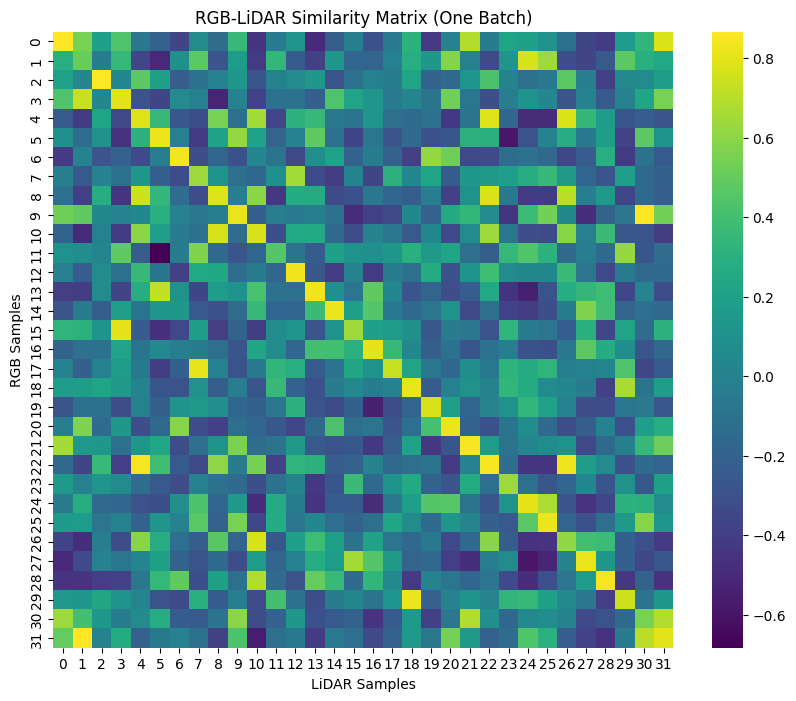

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


cilp_train_loss,█▆▄▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
cilp_val_loss,█▄▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
lr,███▇▇▇▆▆▅▅▄▃▃▂▂▂▁▁▁▁
cilp_train_loss,0.19993
cilp_val_loss,0.61624
epoch,20
lr,0


In [42]:
def plot_similarity_matrix(model, loader):
    model.eval()

    with torch.no_grad():
        # Get one batch
        rgb, lidar, _ = next(iter(loader))
        rgb, lidar = rgb.to(device), lidar.to(device)
        rgb_emb, lidar_emb = model(rgb, lidar)
        
        # Calculate similarity
        logits = torch.matmul(rgb_emb, lidar_emb.T).cpu().numpy()
        
    plt.figure(figsize=(10, 8))
    sns.heatmap(logits, cmap="viridis")
    plt.title("RGB-LiDAR Similarity Matrix (One Batch)")
    plt.xlabel("LiDAR Samples")
    plt.ylabel("RGB Samples")
    
    # Log to W&B
    wandb.log({"similarity_matrix": wandb.Image(plt)})
    plt.show()

def contrastive_loss(rgb_emb, lidar_emb, temperature):
    # Calculate logits: (B, D) @ (D, B) -> (B, B)
    # Scale by exp(temperature) to sharpen distribution
    logits = torch.matmul(rgb_emb, lidar_emb.T) * torch.exp(temperature)
    labels = torch.arange(rgb_emb.size(0)).to(device)
    
    loss_i = nn.CrossEntropyLoss()(logits, labels)
    loss_t = nn.CrossEntropyLoss()(logits.T, labels)
    
    return (loss_i + loss_t) / 2

def train_cilp(model, train_loader, val_loader, config):
    wandb.init(entity="hpi-philipp-kolbe", project="cilp-extended-assessment", config=config, reinit=True, name="CILP_Pretraining")
    
    model = model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config["epochs"])
    
    best_val_loss = float('inf')
    
    print("Starting CILP Pretraining...")
    
    for epoch in range(config["epochs"]):
        model.train()
        train_loss = 0.0
        
        for rgb, lidar, _ in train_loader:
            rgb, lidar = rgb.to(device), lidar.to(device)
            
            optimizer.zero_grad()
            rgb_emb, lidar_emb = model(rgb, lidar)
            loss = contrastive_loss(rgb_emb, lidar_emb, model.temperature)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            
        avg_train_loss = train_loss / len(train_loader)
        scheduler.step()
        
        # Validation
        model.eval()
        val_loss = 0.0
        
        with torch.no_grad():
            for rgb, lidar, _ in val_loader:
                rgb, lidar = rgb.to(device), lidar.to(device)
                rgb_emb, lidar_emb = model(rgb, lidar)
                loss = contrastive_loss(rgb_emb, lidar_emb, model.temperature)
                val_loss += loss.item()
                
        avg_val_loss = val_loss / len(val_loader)
        
        wandb.log({
            "epoch": epoch + 1,
            "cilp_train_loss": avg_train_loss,
            "cilp_val_loss": avg_val_loss,
            "lr": optimizer.param_groups[0]['lr']
        })
        
        print(f"Epoch {epoch+1}/{config['epochs']} - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f}")
        
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            if not os.path.exists("models"):
                os.makedirs("models")
            torch.save(model.state_dict(), "models/cilp_model_best.pth")

    # Log best model to W&B Artifacts
    artifact = wandb.Artifact('cilp_model', type='model')
    artifact.add_file('models/cilp_model_best.pth')
    wandb.log_artifact(artifact)

    plot_similarity_matrix(model, val_loader)

    wandb.finish()
    return model

# Config for CILP
cilp_config = {
    "epochs": 20,
    "lr": 1e-4,
    "weight_decay": 1e-4,
    "embedding_dim": 128,
    "batch_size": BATCH_SIZE
}

# Initialize and Train
cilp_model = CILPModel(embedding_dim=cilp_config["embedding_dim"])
cilp_model = train_cilp(cilp_model, train_loader, val_loader, cilp_config)

Note: Validation loss 0.62 < 3.2!

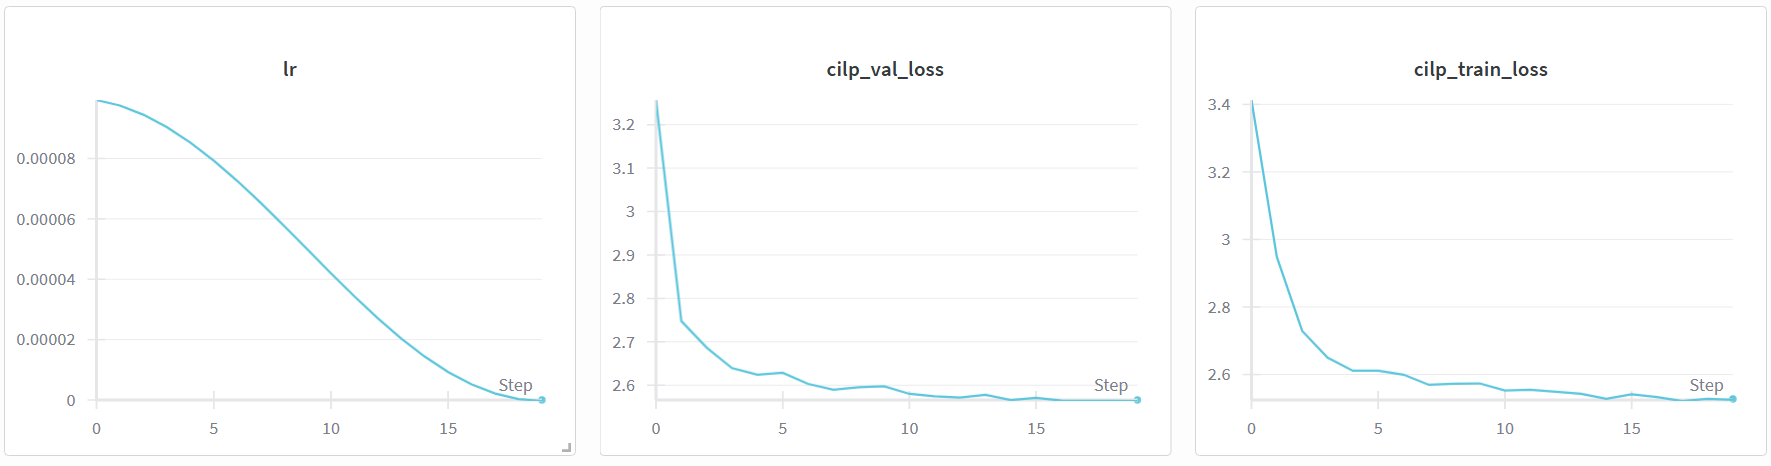

In [43]:
cilp_model.load_state_dict(torch.load("models/cilp_model_best.pth"))

<All keys matched successfully>

## 5. Task 5.2: Cross-Modal Projector

Train a projector to map RGB embeddings to LiDAR embeddings. We freeze the CILP encoders.

### Projector Architecture
The projector is a Multi-Layer Perceptron (MLP) designed to map the RGB embedding space to the LiDAR embedding space.
*   **Input**: RGB Embedding (Dimension: 128)
*   **Hidden Layers**: Two hidden layers with 256 units each, followed by ReLU activations.
*   **Output**: Projected Embedding (Dimension: 128, matching LiDAR space)
*   **Structure**: `Linear(128->256) -> ReLU -> Linear(256->256) -> ReLU -> Linear(256->128)`

### Training Details
*   **Objective**: Minimize the Mean Squared Error (MSE) between the projected RGB embedding and the corresponding ground-truth LiDAR embedding.
*   **Optimizer**: Adam
*   **Learning Rate**: 1e-3, with a StepLR scheduler (decay by 0.1 every 10 epochs).
*   **Constraints**: The pre-trained CILP encoders are **frozen** during this phase to preserve the learned alignment while learning the translation mapping.

In [55]:
class Projector(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(Projector, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, output_dim)
        )
        
    def forward(self, x):
        return self.net(x)

def train_projector(cilp_model, projector, train_loader, val_loader, config):
    wandb.init(entity="hpi-philipp-kolbe", project="cilp-extended-assessment", config=config, reinit=True, name="Projector_Training")
    
    cilp_model.eval() # Freeze CILP
    projector = projector.to(device)
    optimizer = optim.Adam(projector.parameters(), lr=config["lr"])
    criterion = nn.MSELoss()
    
    best_mse = float('inf')
    
    print("Starting Projector Training...")
    
    for epoch in range(config["epochs"]):
        projector.train()
        train_loss = 0.0
        
        for rgb, lidar, _ in train_loader:
            rgb, lidar = rgb.to(device), lidar.to(device)
            
            with torch.no_grad():
                rgb_emb, lidar_emb = cilp_model(rgb, lidar)
            
            optimizer.zero_grad()
            pred_lidar_emb = projector(rgb_emb)
            loss = criterion(pred_lidar_emb, lidar_emb)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            
        avg_train_loss = train_loss / len(train_loader)
        
        # Validation
        projector.eval()
        val_loss = 0.0
        
        with torch.no_grad():
            for rgb, lidar, _ in val_loader:
                rgb, lidar = rgb.to(device), lidar.to(device)
                rgb_emb, lidar_emb = cilp_model(rgb, lidar)
                pred_lidar_emb = projector(rgb_emb)
                loss = criterion(pred_lidar_emb, lidar_emb)
                val_loss += loss.item()
                
        avg_val_loss = val_loss / len(val_loader)
        
        wandb.log({
            "epoch": epoch + 1,
            "proj_train_mse": avg_train_loss,
            "proj_val_mse": avg_val_loss
        })
        
        print(f"Epoch {epoch+1}/{config['epochs']} - Train MSE: {avg_train_loss:.4f} - Val MSE: {avg_val_loss:.4f}")
        
        if avg_val_loss < best_mse:
            best_mse = avg_val_loss
            if not os.path.exists("models"):
                os.makedirs("models")
            torch.save(projector.state_dict(), "models/projector_best.pth")
            
    # Log best model to W&B Artifacts
    artifact = wandb.Artifact('projector_model', type='model')
    artifact.add_file('models/projector_best.pth')
    wandb.log_artifact(artifact)

    wandb.finish()
    return projector

# Config for Projector
proj_config = {
    "epochs": 20,
    "lr": 1e-3,
    "embedding_dim": 128
}

projector = Projector(proj_config["embedding_dim"], proj_config["embedding_dim"])
projector = train_projector(cilp_model, projector, train_loader, val_loader, proj_config)

Starting Projector Training...
Epoch 1/20 - Train MSE: 0.0070 - Val MSE: 0.0052
Epoch 2/20 - Train MSE: 0.0035 - Val MSE: 0.0028
Epoch 3/20 - Train MSE: 0.0018 - Val MSE: 0.0021
Epoch 4/20 - Train MSE: 0.0013 - Val MSE: 0.0019
Epoch 5/20 - Train MSE: 0.0010 - Val MSE: 0.0018
Epoch 6/20 - Train MSE: 0.0009 - Val MSE: 0.0016
Epoch 7/20 - Train MSE: 0.0008 - Val MSE: 0.0016
Epoch 8/20 - Train MSE: 0.0008 - Val MSE: 0.0016
Epoch 9/20 - Train MSE: 0.0007 - Val MSE: 0.0015
Epoch 10/20 - Train MSE: 0.0007 - Val MSE: 0.0015
Epoch 11/20 - Train MSE: 0.0007 - Val MSE: 0.0016
Epoch 12/20 - Train MSE: 0.0007 - Val MSE: 0.0016
Epoch 13/20 - Train MSE: 0.0007 - Val MSE: 0.0016
Epoch 14/20 - Train MSE: 0.0006 - Val MSE: 0.0016
Epoch 15/20 - Train MSE: 0.0006 - Val MSE: 0.0015
Epoch 16/20 - Train MSE: 0.0006 - Val MSE: 0.0015
Epoch 17/20 - Train MSE: 0.0006 - Val MSE: 0.0016
Epoch 18/20 - Train MSE: 0.0006 - Val MSE: 0.0015
Epoch 19/20 - Train MSE: 0.0006 - Val MSE: 0.0015
Epoch 20/20 - Train MSE: 0.0

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
proj_train_mse,█▄▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
proj_val_mse,█▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,20
proj_train_mse,0.00057
proj_val_mse,0.00152


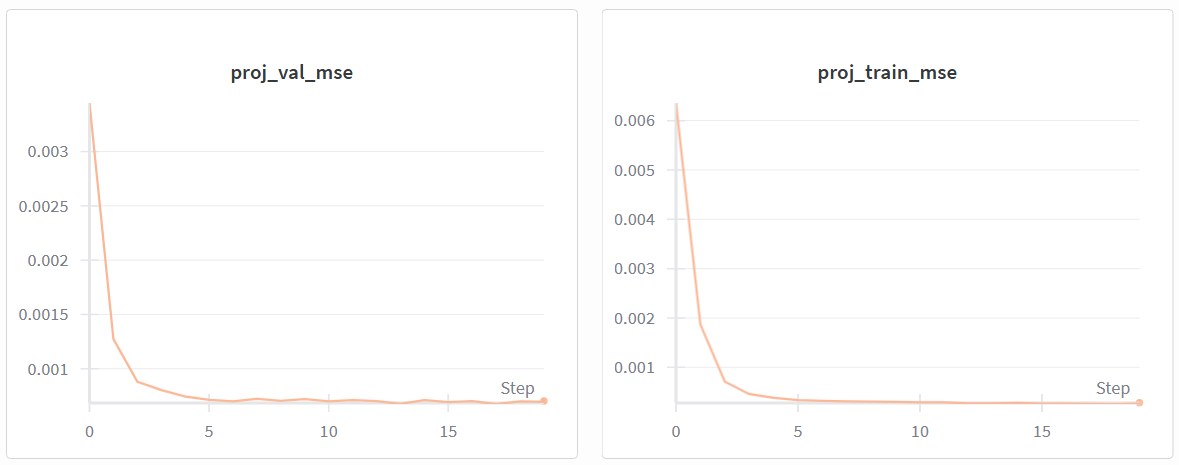

See wandb artifacts for best model.

In [56]:
projector.load_state_dict(torch.load("models/projector_best.pth"))

<All keys matched successfully>

## 6. Task 5.3: Final Classifier

Train a classifier on **Projected RGB embeddings**.

We freeze the CILP encoder and the Projector. We train the classifier head to predict the label (Cube vs Sphere) from the projected embedding. This ensures the classifier learns to handle the specific characteristics of the projected space.

In [60]:
import copy

class Classifier(nn.Module):
    def __init__(self, input_dim, projector):
        super(Classifier, self).__init__()
        # 1. Clone the projector
        self.projector = copy.deepcopy(projector)
        
        # 2. Freeze initially
        for param in self.projector.parameters():
            param.requires_grad = False
            
        self.head = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
        
    def forward(self, x):
        # x is the RGB embedding
        # 1. Project to LiDAR space
        proj_emb = self.projector(x)
        
        # 2. Normalize! (Crucial: Embeddings live on a hypersphere)
        proj_emb = F.normalize(proj_emb, p=2, dim=1)
        
        # 3. Classify
        return self.head(proj_emb)

def train_classifier(cilp_model, classifier, train_loader, val_loader, config):
    wandb.init(entity="hpi-philipp-kolbe", project="cilp-extended-assessment", config=config, reinit=True, name="Classifier_Training")
    
    cilp_model.eval()
    classifier = classifier.to(device)
    
    # Initial Optimizer: Head Only
    optimizer = optim.Adam(classifier.head.parameters(), lr=config["lr"], weight_decay=config.get("weight_decay", 1e-4))
    
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=config.get("factor", 0.5), patience=config.get("patience", 5))
    
    criterion = nn.BCEWithLogitsLoss()
    
    best_acc = 0.0
    
    print("Starting Classifier Training...")
    
    for epoch in range(config["epochs"]):
        # --- Two-Stage Logic ---
        if epoch == config["unfreeze_epoch"]:
            print("\n>>> Unfreezing Projector for Fine-tuning! Reducing LR. <<<")
            # Unfreeze projector
            for param in classifier.projector.parameters():
                param.requires_grad = True
            
            # Re-initialize optimizer for ALL parameters with lower LR
            optimizer = optim.Adam(classifier.parameters(), lr=config["finetune_lr"], weight_decay=config.get("weight_decay", 1e-4))
            scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)
        # -----------------------

        classifier.train()
        # If frozen, keep projector in eval mode. If unfrozen, let it train.
        if epoch < config["unfreeze_epoch"]:
            classifier.projector.eval()
        else:
            classifier.projector.train()
        
        train_loss = 0.0
        train_preds = []
        train_targets = []
        
        for rgb, _, labels in train_loader:
            rgb, labels = rgb.to(device), labels.to(device)
            
            with torch.no_grad():
                # Get RGB embedding from CILP
                rgb_emb = cilp_model.rgb_encoder(rgb)
                rgb_emb = F.normalize(rgb_emb, p=2, dim=1)
            
            optimizer.zero_grad()
            # Forward pass
            outputs = classifier(rgb_emb).squeeze()
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            train_preds.extend(torch.sigmoid(outputs).detach().cpu().numpy() > 0.5)
            train_targets.extend(labels.cpu().numpy())
            
        avg_train_loss = train_loss / len(train_loader)
        train_acc = accuracy_score(train_targets, train_preds)
        
        # Validation
        classifier.eval()
        val_loss = 0.0
        val_preds = []
        val_targets = []
        
        with torch.no_grad():
            for rgb, _, labels in val_loader:
                rgb, labels = rgb.to(device), labels.to(device)
                
                rgb_emb = cilp_model.rgb_encoder(rgb)
                rgb_emb = F.normalize(rgb_emb, p=2, dim=1)
                
                outputs = classifier(rgb_emb).squeeze()
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                
                val_preds.extend(torch.sigmoid(outputs).cpu().numpy() > 0.5)
                val_targets.extend(labels.cpu().numpy())
                
        avg_val_loss = val_loss / len(val_loader)
        val_acc = accuracy_score(val_targets, val_preds)
        
        scheduler.step(val_acc)
        
        wandb.log({
            "epoch": epoch + 1,
            "cls_train_loss": avg_train_loss,
            "cls_train_acc": train_acc,
            "cls_val_loss": avg_val_loss,
            "cls_val_acc": val_acc,
            "lr": optimizer.param_groups[0]['lr']
        })
        
        print(f"Epoch {epoch+1}/{config['epochs']} - Train Loss: {avg_train_loss:.4f} - Val Acc: {val_acc:.4f} - LR: {optimizer.param_groups[0]['lr']:.6f}")
        
        if val_acc > best_acc:
            best_acc = val_acc
            if not os.path.exists("models"):
                os.makedirs("models")
            torch.save(classifier.state_dict(), "models/classifier_best.pth")
            
    # Log best model to W&B Artifacts
    artifact = wandb.Artifact('classifier_model', type='model')
    artifact.add_file('models/classifier_best.pth')
    wandb.log_artifact(artifact)

    wandb.finish()
    return classifier

# Config for Classifier
cls_config = {
    "epochs": 50,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "embedding_dim": 128,
    "factor": 0.5,
    "patience": 5,
    "unfreeze_epoch": 10,   # Warmup head for 10 epochs
    "finetune_lr": 1e-4     # Lower LR for fine-tuning
}

classifier = Classifier(cls_config["embedding_dim"], projector)
classifier = train_classifier(cilp_model, classifier, train_loader, val_loader, cls_config)

Starting Classifier Training...
Epoch 1/50 - Train Loss: 0.6921 - Val Acc: 0.5938 - LR: 0.001000
Epoch 2/50 - Train Loss: 0.6865 - Val Acc: 0.6458 - LR: 0.001000
Epoch 3/50 - Train Loss: 0.6740 - Val Acc: 0.5625 - LR: 0.001000
Epoch 4/50 - Train Loss: 0.6487 - Val Acc: 0.6458 - LR: 0.001000
Epoch 5/50 - Train Loss: 0.6253 - Val Acc: 0.6042 - LR: 0.001000
Epoch 6/50 - Train Loss: 0.5992 - Val Acc: 0.6250 - LR: 0.001000
Epoch 7/50 - Train Loss: 0.5668 - Val Acc: 0.6458 - LR: 0.001000
Epoch 8/50 - Train Loss: 0.5503 - Val Acc: 0.6562 - LR: 0.001000
Epoch 9/50 - Train Loss: 0.5457 - Val Acc: 0.6562 - LR: 0.001000
Epoch 10/50 - Train Loss: 0.5234 - Val Acc: 0.6771 - LR: 0.001000

>>> Unfreezing Projector for Fine-tuning! Reducing LR. <<<
Epoch 11/50 - Train Loss: 0.5123 - Val Acc: 0.6667 - LR: 0.000100
Epoch 12/50 - Train Loss: 0.4895 - Val Acc: 0.6667 - LR: 0.000100
Epoch 13/50 - Train Loss: 0.4877 - Val Acc: 0.6771 - LR: 0.000100
Epoch 14/50 - Train Loss: 0.4808 - Val Acc: 0.6875 - LR: 0.

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


cls_train_acc,▁▁▃▄▄▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇██▇███████████
cls_train_loss,███▇▇▆▅▅▅▄▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
cls_val_acc,▂▄▁▄▃▄▅▅▆▅▆▆▆▆▆▆▇▇▆▆▆█▇██▇▇▇▇▇█▇▇▇▇▇▇▇██
cls_val_loss,█▇▇▄▄▄▃▃▂▃▂▁▁▂▂▂▁▂▁▂▁▁▂▂▂▂▂▁▂▂▂▂▂▂▂▂▂▂▂▂
epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
lr,████████▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
cls_train_acc,0.86042
cls_train_loss,0.34712
cls_val_acc,0.72917
cls_val_loss,0.60061
epoch,50


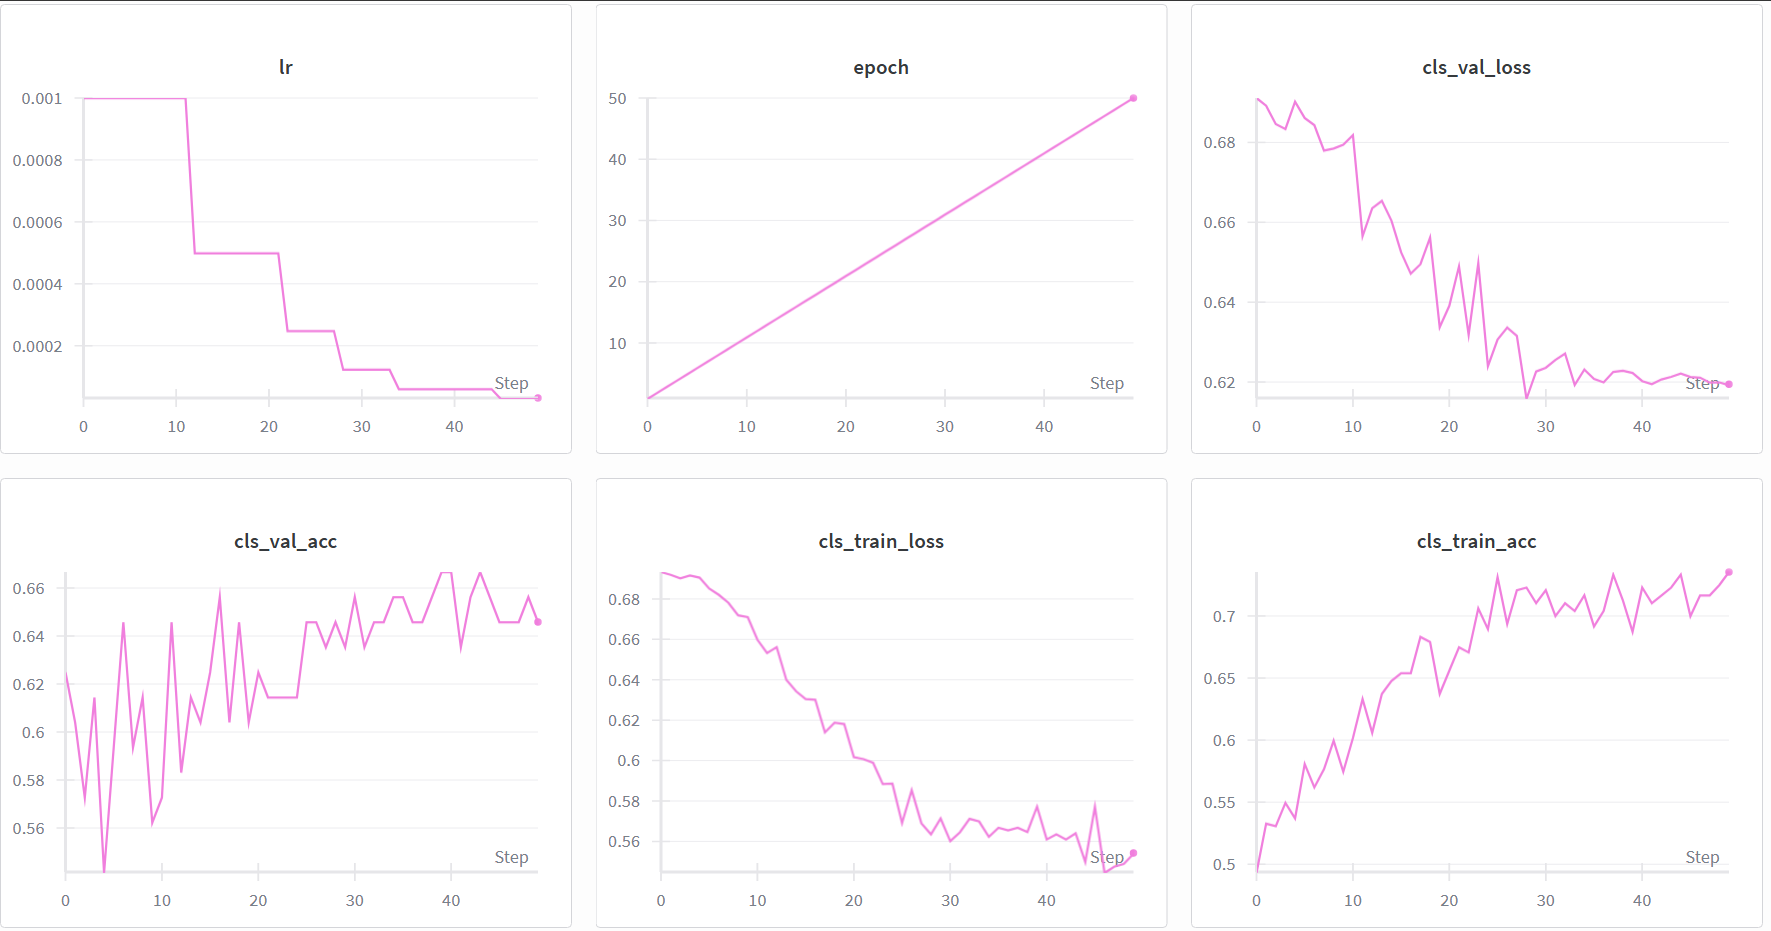

See wandb artifacts for best model.

In [61]:
classifier.load_state_dict(torch.load("models/classifier_best.pth"))

<All keys matched successfully>

## 7. Final Evaluation (RGB -> Projector -> Classifier)

Evaluate the full pipeline on the Test Set.

Evaluating RGB -> Projector -> Classifier pipeline...
Final Test Accuracy: 0.7083
Final Test F1 Score: 0.6744


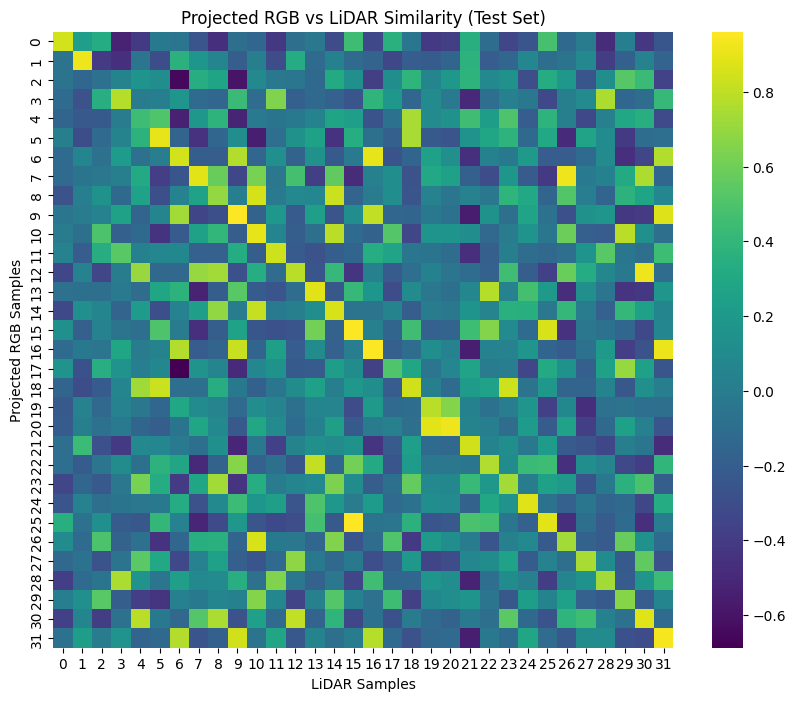

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


test_accuracy,▁
test_f1,▁
test_accuracy,0.70833
test_f1,0.67442


(0.7083333333333334, 0.6744186046511628)

In [62]:
def log_sample_predictions(rgb_imgs, targets, preds, num_samples=5):
    """Log sample predictions to W&B."""
    table = wandb.Table(columns=["Image", "Ground Truth", "Prediction"])
    
    for i in range(min(num_samples, len(rgb_imgs))):
        img = rgb_imgs[i].cpu().permute(1, 2, 0).numpy()
        # Denormalize if needed, here assuming [0,1]
        
        gt_label = "Sphere" if targets[i] == 1 else "Cube"
        pred_label = "Sphere" if preds[i] else "Cube"
        
        table.add_data(wandb.Image(img), gt_label, pred_label)
        
    wandb.log({"sample_predictions": table})

def evaluate_pipeline(cilp_model, classifier, loader):
    wandb.init(entity="hpi-philipp-kolbe", project="cilp-extended-assessment", name="Final_Evaluation", reinit=True)
    
    cilp_model.eval()
    classifier.eval()
    
    all_preds = []
    all_targets = []
    all_rgb = []
    
    print("Evaluating RGB -> Projector -> Classifier pipeline...")
    
    with torch.no_grad():
        for rgb, _, labels in loader:
            rgb, labels = rgb.to(device), labels.to(device)
            
            # 1. RGB Encoder
            rgb_emb = cilp_model.rgb_encoder(rgb)
            rgb_emb = F.normalize(rgb_emb, p=2, dim=1)
            
            # 2. Classifier (Projector + Head)
            outputs = classifier(rgb_emb).squeeze()
            
            preds = torch.sigmoid(outputs).cpu().numpy() > 0.5
            all_preds.extend(preds)
            all_targets.extend(labels.cpu().numpy())
            
            # Store some images for logging
            if len(all_rgb) < 10:
                all_rgb.extend(rgb)
            
    acc = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds)
    
    print(f"Final Test Accuracy: {acc:.4f}")
    print(f"Final Test F1 Score: {f1:.4f}")
    
    wandb.log({
        "test_accuracy": acc,
        "test_f1": f1
    })
    
    # Log samples
    log_sample_predictions(all_rgb, all_targets, all_preds, num_samples=5)

    # Log Similarity Matrix (Projected RGB vs LiDAR)
    rgb, lidar, _ = next(iter(loader))
    rgb, lidar = rgb.to(device), lidar.to(device)
    
    with torch.no_grad():
        # Get Projected RGB Embeddings
        rgb_emb = cilp_model.rgb_encoder(rgb)
        rgb_emb = F.normalize(rgb_emb, p=2, dim=1)
        
        # Use the projector inside the classifier
        proj_emb = classifier.projector(rgb_emb)
        proj_emb = F.normalize(proj_emb, p=2, dim=1)
        
        # Get Ground Truth LiDAR Embeddings
        lidar_emb = cilp_model.lidar_encoder(lidar)
        lidar_emb = F.normalize(lidar_emb, p=2, dim=1)
        
        # Calculate Similarity
        similarity = torch.matmul(proj_emb, lidar_emb.T).cpu().numpy()
        
    plt.figure(figsize=(10, 8))
    sns.heatmap(similarity, cmap="viridis")
    plt.title("Projected RGB vs LiDAR Similarity (Test Set)")
    plt.xlabel("LiDAR Samples")
    plt.ylabel("Projected RGB Samples")
    wandb.log({"projected_similarity_matrix": wandb.Image(plt)})
    plt.show()
    
    wandb.finish()
    return acc, f1

# Run Evaluation on Test Set
evaluate_pipeline(cilp_model, classifier, test_loader)

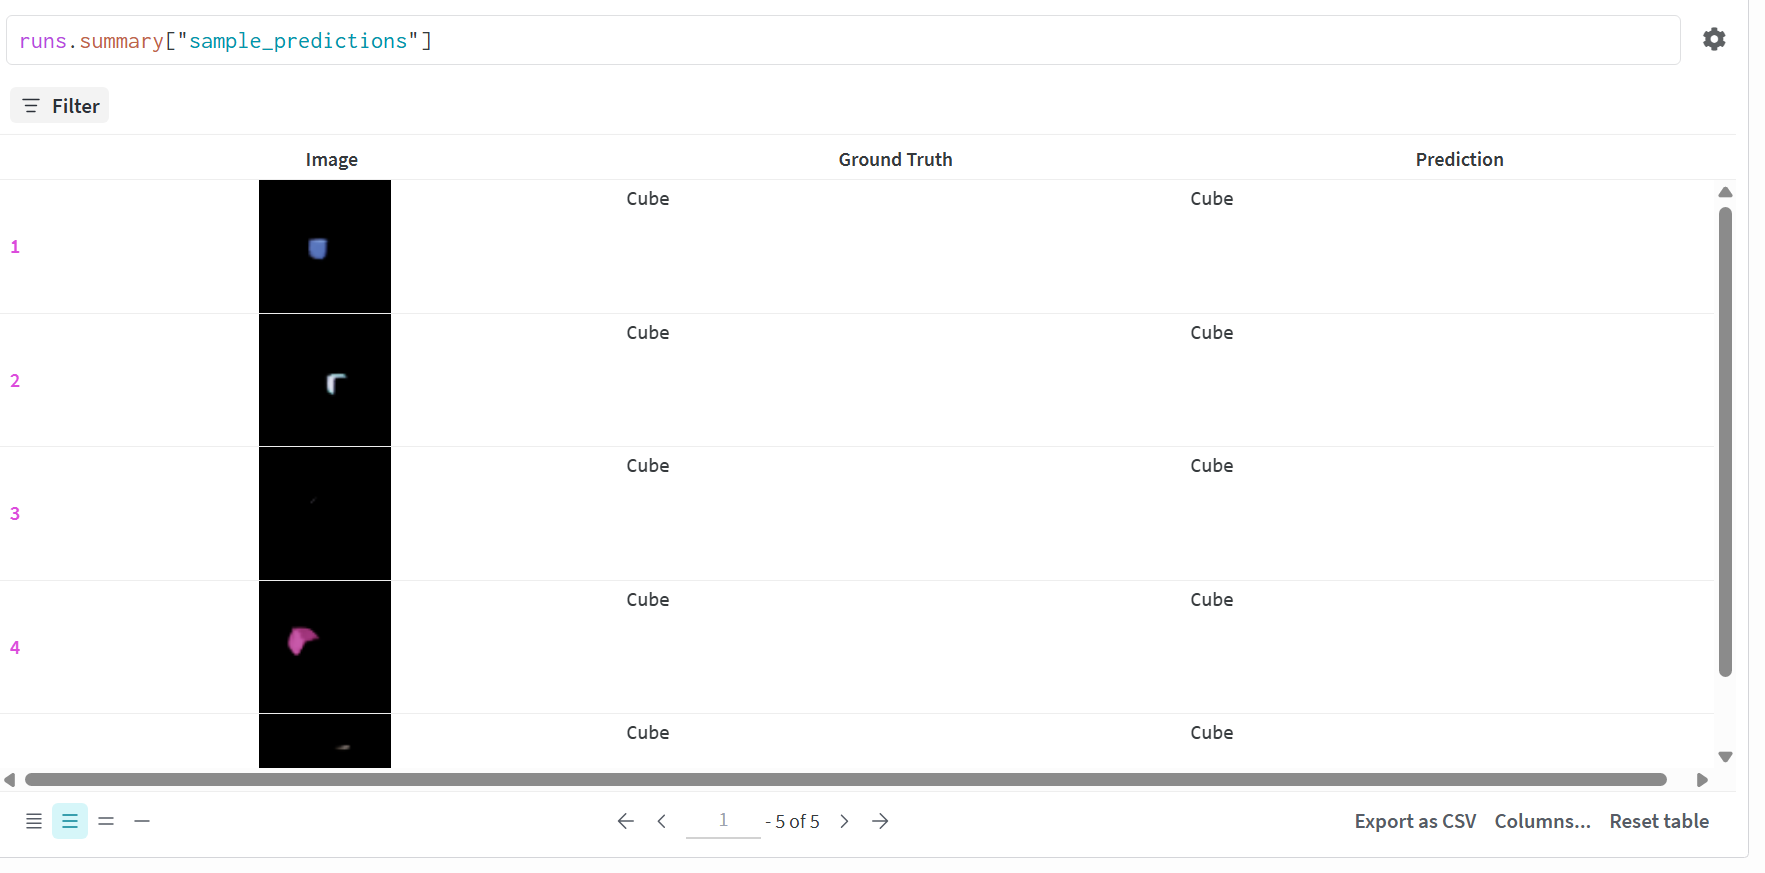

## Model Checkpoints Note

Due to GitHub file size limits, the trained model checkpoints (`*.pth`) are not included in the repository. They are stored as **W&B Artifacts** in the [cilp-extended-assessment](https://wandb.ai/hpi-philipp-kolbe/cilp-extended-assessment/artifacts/model/classifier_model) project.